# EDA y Análisis Competitivo de Modelos: HIS-05 (Monitor de Saturación)

**Objetivo:** Desarrollar y comparar tres enfoques algorítmicos para predecir la saturación y los tiempos de espera en Urgencias y Admisión.

**Fuentes de Datos (Parquet):**
* `NOTAMEDICAURG.parquet`: Tiempos exactos de llegada (`Llegada_Fecha`, `Llegada_Hora`) y atención (`AtMed_Hora`).
* `TRIAGE.parquet`: Nivel de gravedad del paciente (`Triage`).
* `HOSPAC.parquet`: Flujo general de ingresos (`p_fec_lld`, `p_hra_lld`).

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Configuración de la ruta
DATA_DIR = Path("../data/01_raw")

# Carga del archivo Parquet
df_urgencias = pd.read_parquet(DATA_DIR / "NOTAMEDICAURG.parquet")

# 1. Mostrar todas las columnas disponibles
print("=== COLUMNAS DISPONIBLES EN NOTAMEDICAURG ===")
for i, col in enumerate(df_urgencias.columns):
    print(f"{i+1}. {col}")

=== COLUMNAS DISPONIBLES EN NOTAMEDICAURG ===
1. Indice
2. Expediente
3. Edad
4. Sexo
5. ClaveIngreso
6. Fecha
7. Hora
8. Usuario
9. Medico
10. Especialidad
11. LlegadaServicio
12. MotivoConsulta
13. Triage
14. AtMed_Hora
15. Subjetivo
16. Objetivo
17. Apreciativo
18. Diag1
19. DesDiag1
20. Diag2
21. DesDiag2
22. Pplan
23. Pronostico
24. Accidente
25. Observacion
26. Tpo_Paciente
27. Destino_Hora
28. Destino
29. Especifique
30. Especialista
31. Plan1
32. Destino_Fecha
33. Consulta_Fecha
34. Consulta_Hora
35. Observacion_Fecha
36. Observacion_Hora
37. Salida
38. Llegada_Fecha
39. Llegada_Hora
40. P_Fol_Cto
41. P_Fol_Ext
42. Diag3
43. DesDiag3
44. TipoUrgencias
45. prox_cita
46. prox_cita1
47. MotivoAtencion
48. Diag1Sal
49. DesDiag1Sal
50. Responsable
51. NombreResp
52. EstatusReg
53. DiagIng2
54. DesDiagIng2
55. DiagIng3
56. DesDiagIng3
57. Diag4
58. DesDiag4
59. Diag5
60. DesDiag5
61. Diag6
62. DesDiag6
63. MedicoLegal
64. MedLegImp
65. IndiceSV
66. SoloCEX
67. LugarHecho
68. CalleAve

In [3]:
# 1. Copiamos solo lo necesario por eficiencia
df_ts_prep = df_urgencias[['Indice', 'Llegada_Fecha', 'Llegada_Hora', 'AtMed_Hora']].copy()

# 2. Función robusta (limpia espacios y rellena ceros)
def parse_datetime_robust(df, date_col, time_col):
    # Convertir a texto y quitar espacios
    d = df[date_col].astype(str).str.strip()
    t = df[time_col].astype(str).str.split('.').str[0].str.strip() # Quita decimales si los hay
    
    # Rellenar con ceros (ej: 93000 -> 093000) para que tenga 6 dígitos
    t = t.str.zfill(6)
    
    # Manejar nulos textuales antes de la concatenación
    d = d.replace(['nan', 'NaT', 'None', ''], '')
    t = t.replace(['nan', 'NaT', 'None', '000000', '0', ''], '')
    
    # Unir fecha y hora (esto evita el TypeError al sumar objetos pd.NA)
    datetime_str = d + " " + t
    datetime_str = datetime_str.str.strip()
    datetime_str = datetime_str.replace('', pd.NA)
    
    # Parseo flexible: Pandas intentará deducir el formato. Si falla, pone NaT.
    return pd.to_datetime(datetime_str, errors='coerce')

# Aplicamos la función
df_ts_prep['timestamp_llegada'] = parse_datetime_robust(df_ts_prep, 'Llegada_Fecha', 'Llegada_Hora')
df_ts_prep['timestamp_atencion'] = parse_datetime_robust(df_ts_prep, 'Llegada_Fecha', 'AtMed_Hora')

# Diagnóstico de limpieza
print(f"Total registros originales: {len(df_ts_prep)}")
print(f"Llegadas parseadas con éxito: {df_ts_prep['timestamp_llegada'].notna().sum()}")
print(f"Atenciones parseadas con éxito: {df_ts_prep['timestamp_atencion'].notna().sum()}")

Total registros originales: 22878
Llegadas parseadas con éxito: 22878
Atenciones parseadas con éxito: 22878


In [4]:
df_ts_prep.head()

,Indice,Llegada_Fecha,Llegada_Hora,AtMed_Hora,timestamp_llegada,timestamp_atencion
0,25.0,20241004,105539,,2024-10-04 10:55:39,2024-10-04
1,26.0,20241004,123637,,2024-10-04 12:36:37,2024-10-04
2,28.0,20241004,123637,,2024-10-04 12:36:37,2024-10-04
3,27.0,20241004,130500,,2024-10-04 13:05:00,2024-10-04
4,29.0,20241004,130500,,2024-10-04 13:05:00,2024-10-04


In [5]:
# Seleccionar fila random de df
df_ts_prep.sample(1)

,Indice,Llegada_Fecha,Llegada_Hora,AtMed_Hora,timestamp_llegada,timestamp_atencion
18113,2774.0,20250215,221339,,2025-02-15 22:13:39,2025-02-15


In [8]:
# AtMed_Hora, verificar NULL o NaN
print("Valores únicos en AtMed_Hora:")
print(df_ts_prep['AtMed_Hora'].unique())
print("Número de registros con AtMed_Hora nulo o NaN:")
print(df_ts_prep['AtMed_Hora'].isna().sum())
print("Número de registros con AtMed_Hora vacío o '0':")
print(((df_ts_prep['AtMed_Hora'].astype(str).str.strip() == '0') | (df_ts_prep['AtMed_Hora'].astype(str).str.strip() == '')).sum())

print("-------"*10)
# Llegada_Fecha, verificar NULL o NaN
print("Valores únicos en Llegada_Fecha:")
print(df_ts_prep['Llegada_Fecha'].unique())
print("Número de registros con Llegada_Fecha nulo o NaN:")
print(df_ts_prep['Llegada_Fecha'].isna().sum())
print("Número de registros con Llegada_Fecha vacío:")
print((df_ts_prep['Llegada_Fecha'].astype(str).str.strip() == '').sum())




Valores únicos en AtMed_Hora:
<ArrowStringArray>
['      ']
Length: 1, dtype: str
Número de registros con AtMed_Hora nulo o NaN:
0
Número de registros con AtMed_Hora vacío o '0':
22878
----------------------------------------------------------------------
Valores únicos en Llegada_Fecha:
<ArrowStringArray>
['20241004', '20241005', '20241007', '20241009', '20241010', '19630515',
 '20241011', '20241012', '20241013', '20241014',
 ...
 '19780801', '19830506', '19770730', '20250829', '20250123', '19751231',
 '19740422', '20040426', '20010914', '20250915']
Length: 281, dtype: str
Número de registros con Llegada_Fecha nulo o NaN:
0
Número de registros con Llegada_Fecha vacío:
0


Nota. Como ya vimos que ``AtMed_Hora`` no sirve porque esta todo vacio, lo que haremos sera pivotear a hacer pronosticos de demanda. En lugar de predecir el "tiempo de espera" (que es defectuoso por captura humana), predecimos el Volumen de Llegadas (Demanda). Si el modelo predice que mañana a las 10:00 AM van a llegar 30 pacientes de golpe (cuando lo normal son 10), el hospital sabe que habrá saturación y tomará medidas.

In [9]:
# 1. Copiamos solo lo que necesitamos
df_ts_prep = df_urgencias[['Indice', 'Llegada_Fecha', 'Llegada_Hora']].copy()

# 2. Función robusta de parseo
def parse_datetime_robust(df, date_col, time_col):
    # Convertir a texto, quitar espacios y decimales
    d = df[date_col].astype(str).str.strip()
    t = df[time_col].astype(str).str.split('.').str[0].str.strip()
    
    # Rellenar horas con ceros para tener formato HHMMSS (6 dígitos)
    t = t.str.zfill(6)
    
    # Manejar nulos o vacíos
    d = d.replace(['nan', 'NaT', 'None', ''], pd.NA)
    t = t.replace(['nan', 'NaT', 'None', '000000', '0', '      '], pd.NA)
    
    datetime_str = d + " " + t
    return pd.to_datetime(datetime_str, errors='coerce')

# Creamos la marca de tiempo de llegada
df_ts_prep['timestamp_llegada'] = parse_datetime_robust(df_ts_prep, 'Llegada_Fecha', 'Llegada_Hora')

# Eliminamos filas donde realmente no hay registro de cuándo llegó el paciente
df_validos = df_ts_prep.dropna(subset=['timestamp_llegada']).copy()

print(f"Total registros originales: {len(df_ts_prep)}")
print(f"Llegadas válidas para la serie de tiempo: {len(df_validos)}")

df_validos.head()

Total registros originales: 22878
Llegadas válidas para la serie de tiempo: 22878


,Indice,Llegada_Fecha,Llegada_Hora,timestamp_llegada
0,25.0,20241004,105539,2024-10-04 10:55:39
1,26.0,20241004,123637,2024-10-04 12:36:37
2,28.0,20241004,123637,2024-10-04 12:36:37
3,27.0,20241004,130500,2024-10-04 13:05:00
4,29.0,20241004,130500,2024-10-04 13:05:00


In [10]:
# Revisar fecha mas antigua y mas reciente
print(f"Fecha más antigua de llegada: {df_validos['timestamp_llegada'].min()}")
print(f"Fecha más reciente de llegada: {df_validos['timestamp_llegada'].max()}")

Fecha más antigua de llegada: 1963-05-15 13:17:47
Fecha más reciente de llegada: 2026-02-27 17:15:22


Registros eliminados por fechas absurdas: 33

Muestra de las primeras horas (Ya corregidas):


,pacientes_llegando
timestamp_llegada,
2024-10-04 10:00:00,1
2024-10-04 11:00:00,0
2024-10-04 12:00:00,2
2024-10-04 13:00:00,3
2024-10-04 14:00:00,0
2024-10-04 15:00:00,0
2024-10-04 16:00:00,0
2024-10-04 17:00:00,0
2024-10-04 18:00:00,0


------------------------------


,pacientes_llegando
timestamp_llegada,
2026-01-30 07:00:00,0
2026-01-30 08:00:00,0
2026-01-30 09:00:00,0
2026-01-30 10:00:00,0
2026-01-30 11:00:00,0
2026-01-30 12:00:00,0
2026-01-30 13:00:00,0
2026-01-30 14:00:00,0
2026-01-30 15:00:00,0


------------------------------


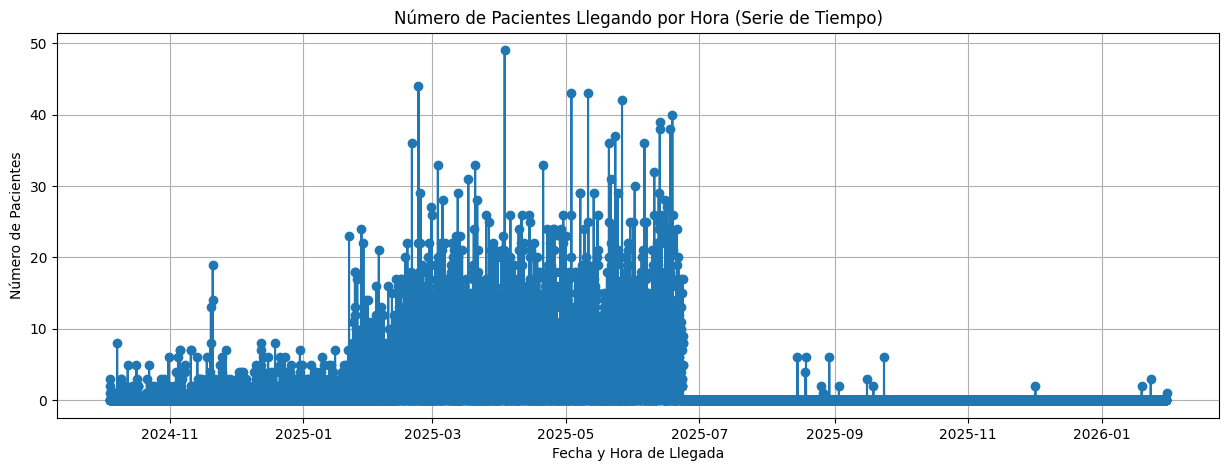

In [11]:
# 1. Filtro de Fechas Lógicas (Eliminar errores de captura como 1963 o 2099)

fecha_minima = pd.to_datetime('2020-01-01')
fecha_maxima = pd.to_datetime('2026-02-27')

df_validos_limpio = df_validos[
    (df_validos['timestamp_llegada'] >= fecha_minima) & 
    (df_validos['timestamp_llegada'] <= fecha_maxima)
].copy()

print(f"Registros eliminados por fechas absurdas: {len(df_validos) - len(df_validos_limpio)}")

# 2. Creación de la Serie de Tiempo de Demanda (Ahora sí, continua y lógica)
df_ts = df_validos_limpio.set_index('timestamp_llegada').resample('1h').agg(
    pacientes_llegando=('Indice', 'count')
).fillna(0)

# Diagnóstico de la serie
print("\nMuestra de las primeras horas (Ya corregidas):")
display(df_ts.head(10))
print("-" * 30)

display(df_ts.tail(10))
print("-" * 30)

# Graficamos el rango de datos para visualizar la tendencia de llegada de pacientes por hora
plt.figure(figsize=(15, 5))
plt.plot(df_ts.index, df_ts['pacientes_llegando'], marker='o', linestyle='-')
plt.title('Número de Pacientes Llegando por Hora (Serie de Tiempo)')
plt.xlabel('Fecha y Hora de Llegada')
plt.ylabel('Número de Pacientes')
plt.grid()
plt.show()

# URGENTE!

Explorar que paso en el lapso de 2025-02 y 2025-07, porque eso si no es normal que toda la data se concentre en esos lapsos y los demas estan "normales" (por decirlo de una forma).


## Modelo 1: Análisis Clásico de Series de Tiempo (ARIMA/SARIMA)

**Justificación de Uso (Baseline):**
Antes de implementar Deep Learning, es obligatorio establecer una línea base estadística. Los modelos de la familia ARIMA (AutoRegressive Integrated Moving Average) asumen dependencias lineales en el tiempo.
* **Propósito:** Entender la "anatomía" del flujo hospitalario. Nos permitirá realizar la descomposición de la serie para identificar la *Estacionalidad* (picos diarios a ciertas horas o picos semanales los lunes) y la *Tendencia* a largo plazo.
* **Limitación a superar:** Estos modelos fallan drásticamente al intentar incluir variables categóricas complejas (como qué médicos están de turno o fluctuaciones abruptas por accidentes masivos).

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# 1. Prueba de Estacionariedad (Dickey-Fuller)
print("--- Diagnóstico Estadístico ---")
adf_result = adfuller(df_ts['pacientes_llegando'])
print(f"P-value de ADF: {adf_result[1]:.5f}")
if adf_result[1] < 0.05:
    print("Resultado: La serie es estacionaria (No tiene tendencias a largo plazo que desestabilicen el modelo).")
else:
    print("Resultado: La serie NO es estacionaria (Requiere diferenciación).")

--- Diagnóstico Estadístico ---
P-value de ADF: 0.00038
Resultado: La serie es estacionaria (No tiene tendencias a largo plazo que desestabilicen el modelo).


In [13]:
# 2. Descomposición Estacional (Buscamos patrones diarios de 24h)
# Tomamos solo el último mes para que la gráfica sea legible (aprox 720 horas)
mes_reciente = df_ts.tail(720)
descomposicion = seasonal_decompose(mes_reciente['pacientes_llegando'], model='additive', period=24)

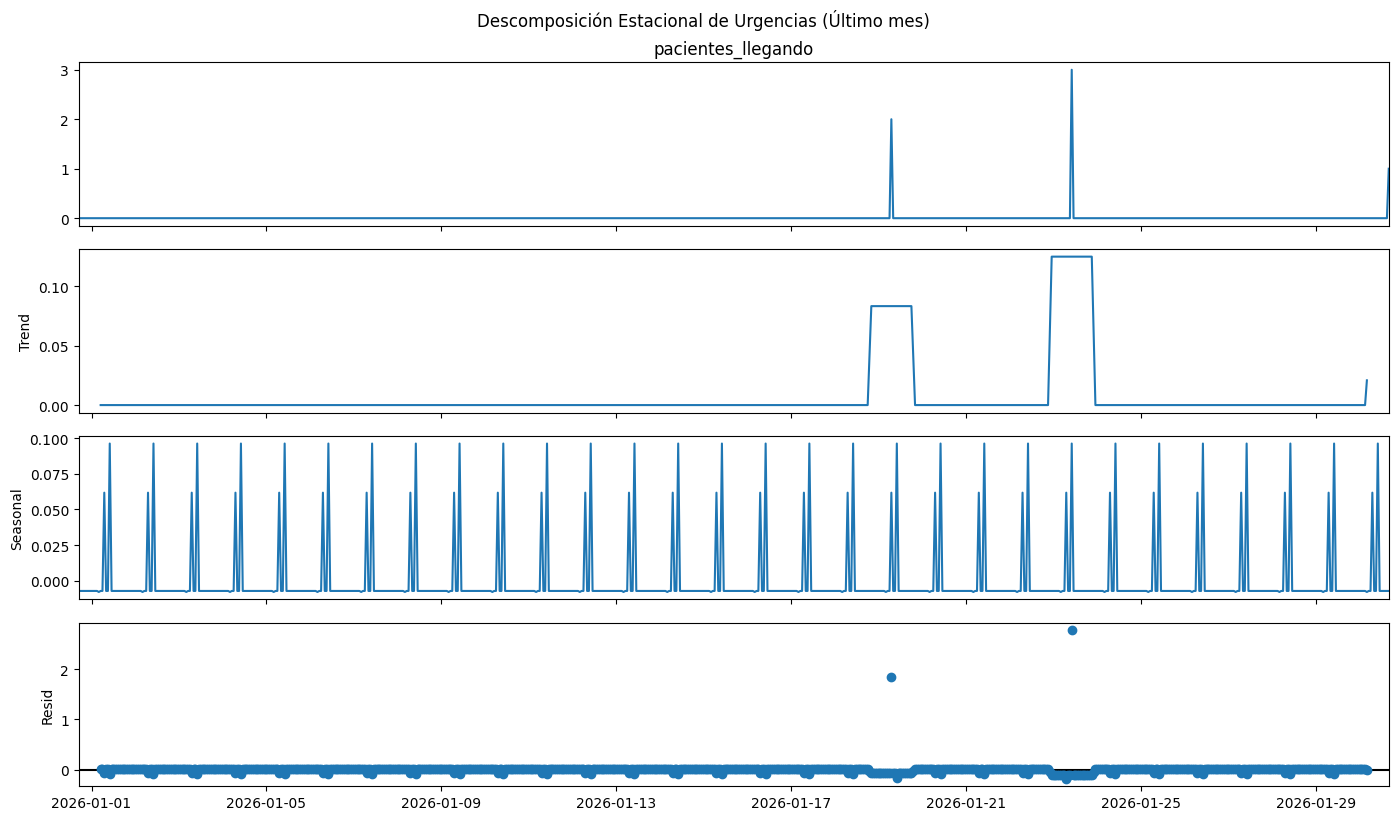

In [14]:
plt.rc('figure', figsize=(14, 8))
descomposicion.plot()
plt.suptitle('Descomposición Estacional de Urgencias (Último mes)', y=1.02)
plt.show()

Basados en el ultimo mes de datos registrados, podemos concluir que si tiene cierta estacionalidad, lo que al menos en este mes en particular no hay tendencia global fuerte o a largo plazo. Aunque tambien es demasiado dispersa (son demasiados ceros) con eventos extremos, dando a entender que son outliers, pero como estamos hablando de urgencias, realmente un accidente o un incidente puede pasar a cualquier hora, en cualquier momento.

In [15]:
# 3. Entrenamiento de Línea Base (ARIMA)
# Separamos 80% entrenamiento y 20% prueba
train_size = int(len(df_ts) * 0.8)
train, test = df_ts['pacientes_llegando'][:train_size], df_ts['pacientes_llegando'][train_size:]

In [16]:
# Entrenamos un modelo auto-regresivo sencillo
print("\n--- Entrenando Baseline ARIMA(2,0,1) ---")
modelo_arima = ARIMA(train, order=(2, 0, 1)).fit()
predicciones_arima = modelo_arima.forecast(steps=len(test))

# Métrica de Error a vencer
mae_baseline = mean_absolute_error(test, predicciones_arima)
print(f"-> MAE Baseline (ARIMA): {mae_baseline:.2f} pacientes por hora de error promedio")


--- Entrenando Baseline ARIMA(2,0,1) ---
-> MAE Baseline (ARIMA): 2.44 pacientes por hora de error promedio


## Modelo 2: Redes Neuronales Recurrentes (LSTM)

**Justificación (Modelo Competitivo 1):**
Las redes LSTM capturan la **memoria secuencial**. A diferencia de ARIMA (que promedia los lags pasados), la LSTM aprende el "efecto de arrastre" dinámico. Si hubo un pico anormal de llegadas hace 3 horas, la red mantiene ese estado oculto para ajustar la predicción actual, imitando cómo un cuello de botella logístico se propaga en el tiempo.

In [17]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import numpy as np

# 1. Escalamiento de datos (Las Redes Neuronales son sensibles a la magnitud)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_ts[['pacientes_llegando']])

# 2. Creación de Ventanas Deslizantes
# La IA mirará las últimas 6 horas para intentar adivinar la hora siguiente
def create_dataset(dataset, time_step=6):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_steps = 6
X_seq, Y_seq = create_dataset(scaled_data, time_step=time_steps)

In [18]:
# Reshape para que Keras lo acepte: [samples, time steps, features]
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# 3. Arquitectura LSTM
model_lstm = Sequential([
    Input(shape=(time_steps, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])

In [19]:
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
print("Estructura de la Red Neuronal Recurrente lista:")
model_lstm.summary()

Estructura de la Red Neuronal Recurrente lista:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Entrenar
historial = model_lstm.fit(X_seq, Y_seq, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0066 - val_loss: 8.9368e-05
Epoch 2/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060 - val_loss: 1.2306e-04
Epoch 3/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058 - val_loss: 1.4480e-04
Epoch 4/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - val_loss: 2.2816e-05
Epoch 5/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - val_loss: 6.5588e-05
Epoch 6/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 2.4838e-05
Epoch 7/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 5.2494e-04
Epoch 8/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - val_loss: 5.5877e-05
Epoch 9/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 1.2499e-04
Epoch 10/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 3.5358e-05


In [21]:
# Comparación de predicciones (ARIMA vs LSTM)
predicciones_lstm = model_lstm.predict(X_seq)
predicciones_lstm_rescaled = scaler.inverse_transform(predicciones_lstm)

# Evaluamos el MAE de LSTM
mae_lstm = mean_absolute_error(df_ts['pacientes_llegando'][time_steps+1:], predicciones_lstm_rescaled.flatten())
print(f"\n-> MAE LSTM: {mae_lstm:.2f} pacientes por hora de error promedio")

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

-> MAE LSTM: 1.76 pacientes por hora de error promedio


## Modelo 3: Transformers y Variables Exógenas (Estado del Arte)

**Justificación (Modelo Competitivo 2):**
El verdadero valor del hospital no está solo en contar cuántos pacientes llegan, sino **qué tan graves están**. Los Transformers nos permiten agregar *variables exógenas* a nuestra serie de tiempo. Cruzaremos nuestra demanda con el nivel de `Triage` promedio. Si la atención descubre que la demanda sube cuando predominan los Triages nivel 2 (emergencias graves), el modelo predecirá cuellos de botella con mucha mayor precisión que una serie de tiempo aislada.

In [22]:
# 1. Cargamos y limpiamos el Triage
df_triage = pd.read_parquet(DATA_DIR / "TRIAGE.parquet")
df_triage_clean = df_triage[['Indice', 'Fecha', 'Hora', 'Triage']].copy()

# Reutilizamos tu función robusta
df_triage_clean['timestamp_triage'] = parse_datetime_robust(df_triage_clean, 'Fecha', 'Hora')
df_triage_clean = df_triage_clean.dropna(subset=['timestamp_triage']).copy()

# 2. Convertimos el Nivel de Triage a número para sacar promedios
# Si hay basura, coercionamos a NaN
df_triage_clean['Triage_Num'] = pd.to_numeric(df_triage_clean['Triage'], errors='coerce')

# 3. Agrupamos por hora para sacar la severidad promedio
# Llenamos con nivel 3 (Urgencia menor estandar) si la hora está vacía
df_triage_ts = df_triage_clean.set_index('timestamp_triage').resample('1h').agg(
    triage_promedio=('Triage_Num', 'mean')
).fillna(3)

# 4. Unimos la Demanda (df_ts) con la Severidad (df_triage_ts)
df_transformer = df_ts.join(df_triage_ts, how='left')

# Si hay huecos tras el cruce (ej. llegaron pacientes pero no se les capturó triage)
df_transformer['triage_promedio'] = df_transformer['triage_promedio'].fillna(3)

# 5. Agregamos características temporales estáticas (Contexto global)
df_transformer['hora_dia'] = df_transformer.index.hour
df_transformer['dia_semana'] = df_transformer.index.dayofweek
df_transformer['es_fin_semana'] = df_transformer['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

print("\n--- Matriz Multimodal Lista para un Transformer (TFT) ---")
display(df_transformer.head(10))

# Ahora el modelo tiene 5 columnas para aprender, no solo 1.


--- Matriz Multimodal Lista para un Transformer (TFT) ---


,pacientes_llegando,triage_promedio,hora_dia,dia_semana,es_fin_semana
timestamp_llegada,,,,,
2024-10-04 10:00:00,1,3.0,10,4,0
2024-10-04 11:00:00,0,3.0,11,4,0
2024-10-04 12:00:00,2,3.0,12,4,0
2024-10-04 13:00:00,3,3.0,13,4,0
2024-10-04 14:00:00,0,3.0,14,4,0
2024-10-04 15:00:00,0,3.0,15,4,0
2024-10-04 16:00:00,0,3.0,16,4,0
2024-10-04 17:00:00,0,3.0,17,4,0
2024-10-04 18:00:00,0,3.0,18,4,0


In [23]:
# 1. Cargamos y limpiamos el Triage
df_triage = pd.read_parquet(DATA_DIR / "TRIAGE.parquet")
df_triage_clean = df_triage[['Indice', 'Fecha', 'Hora', 'Triage']].copy()

# Reutilizamos tu función robusta
df_triage_clean['timestamp_triage'] = parse_datetime_robust(df_triage_clean, 'Fecha', 'Hora')
df_triage_clean = df_triage_clean.dropna(subset=['timestamp_triage']).copy()

In [24]:
# 2. Convertimos el Nivel de Triage a número para sacar promedios
# Si hay basura, coercionamos a NaN
df_triage_clean['Triage_Num'] = pd.to_numeric(df_triage_clean['Triage'], errors='coerce')

In [25]:
# 3. Agrupamos por hora para sacar la severidad promedio
# Llenamos con nivel 3 (Urgencia menor estandar) si la hora está vacía
df_triage_ts = df_triage_clean.set_index('timestamp_triage').resample('1h').agg(
    triage_promedio=('Triage_Num', 'mean')
).fillna(3)

In [26]:
# 4. Unimos la Demanda (df_ts) con la Severidad (df_triage_ts)
df_transformer = df_ts.join(df_triage_ts, how='left')

# Si hay huecos tras el cruce (ej. llegaron pacientes pero no se les capturó triage)
df_transformer['triage_promedio'] = df_transformer['triage_promedio'].fillna(3)

# 5. Agregamos características temporales estáticas (Contexto global)
df_transformer['hora_dia'] = df_transformer.index.hour
df_transformer['dia_semana'] = df_transformer.index.dayofweek
df_transformer['es_fin_semana'] = df_transformer['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

print("\n--- Matriz Multimodal Lista para un Transformer (TFT) ---")
display(df_transformer.head(10))


--- Matriz Multimodal Lista para un Transformer (TFT) ---


,pacientes_llegando,triage_promedio,hora_dia,dia_semana,es_fin_semana
timestamp_llegada,,,,,
2024-10-04 10:00:00,1,3.0,10,4,0
2024-10-04 11:00:00,0,3.0,11,4,0
2024-10-04 12:00:00,2,3.0,12,4,0
2024-10-04 13:00:00,3,3.0,13,4,0
2024-10-04 14:00:00,0,3.0,14,4,0
2024-10-04 15:00:00,0,3.0,15,4,0
2024-10-04 16:00:00,0,3.0,16,4,0
2024-10-04 17:00:00,0,3.0,17,4,0
2024-10-04 18:00:00,0,3.0,18,4,0


## Entrenamiento del Temporal Fusion Transformer (TFT)

**Consideración Técnica:**
Utilizaremos `pytorch-forecasting`. Esta librería requiere que nuestro DataFrame tenga dos ajustes técnicos:
1. Un `time_idx`: Un índice de tiempo numérico entero y continuo (no fechas).
2. Un `group_id`: Un identificador de serie. Como solo estamos prediciendo un hospital, crearemos una columna estática llamada 'urgencias'.

El TFT es tan potente porque separa las variables en:
* **Target:** Lo que queremos predecir (`pacientes_llegando`).
* **Time-varying known:** Cosas que ya sabemos del futuro (`hora_dia`, `dia_semana`).
* **Time-varying unknown:** Cosas que no sabremos en el futuro hasta que pasen (`triage_promedio`).

In [30]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
import numpy as np

# 1. Ajustes técnicos al DataFrame
df_tft = df_transformer.reset_index().copy()
df_tft['time_idx'] = np.arange(len(df_tft)) # Índice entero incremental
df_tft['group'] = 'urgencias'               # ID de grupo

# Asegurar tipos de datos (las categóricas deben ser strings)
df_tft['hora_dia'] = df_tft['hora_dia'].astype(str)
df_tft['dia_semana'] = df_tft['dia_semana'].astype(str)
df_tft['es_fin_semana'] = df_tft['es_fin_semana'].astype(str)

# CORRECCIÓN DE BUG: PyTorch exige que los "targets" y reales sean float
df_tft['pacientes_llegando'] = df_tft['pacientes_llegando'].astype(float)
df_tft['triage_promedio'] = df_tft['triage_promedio'].astype(float)

# 2. Parámetros de la ventana de tiempo
max_prediction_length = 6  # Predecir las siguientes 6 horas
max_encoder_length = 24    # Mirando las 24 horas pasadas

# 3. Definición del Dataset del Transformer
training_cutoff = df_tft["time_idx"].max() - max_prediction_length

training_dataset = TimeSeriesDataSet(
    df_tft[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="pacientes_llegando",
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2, 
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    time_varying_known_categoricals=["hora_dia", "dia_semana", "es_fin_semana"],
    time_varying_unknown_reals=["pacientes_llegando", "triage_promedio"],
    target_normalizer=GroupNormalizer(
        groups=["group"], transformation="softplus"
    ),  # softplus ahora funcionará porque los datos son float
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Creamos los DataLoaders para PyTorch
validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, df_tft, predict=True, stop_randomization=True)
train_dataloader = training_dataset.to_dataloader(train=True, batch_size=32, num_workers=0)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

print("¡DataLoaders del Transformer creados con éxito!")

¡DataLoaders del Transformer creados con éxito!


In [36]:
import lightning.pytorch as pl
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# 1. Instanciamos el modelo TFT
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.03,
    hidden_size=16,           # Neuronas por capa
    attention_head_size=1,    # Cabezales de atención
    dropout=0.1,
    hidden_continuous_size=8, 
    loss=QuantileLoss(),      # Nos dará rangos (ej. "llegarán entre 10 y 15 pacientes")
    reduce_on_plateau_patience=4,
)

print(f"Número de parámetros del modelo: {tft.size()/1e3:.1f} k")

# 2. Configuración del Trainer moderno (PyTorch Lightning 2.0+)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",       # Detecta GPU o CPU automáticamente
    devices=1,
    gradient_clip_val=0.1,
)

# 3. Iniciar el Entrenamiento
print("\n--- Iniciando el Entrenamiento del Transformer ---")
trainer.fit(
    tft, 
    train_dataloaders=train_dataloader, 
    val_dataloaders=val_dataloader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\rprie\Documents\GitHub\tca-reto\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, wh

Número de parámetros del modelo: 19.3 k

--- Iniciando el Entrenamiento del Transformer ---


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    253 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     96 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    912 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 286                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\rprie\Documents\GitHub\tca-reto\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

c:\Users\rprie\Documents\GitHub\tca-reto\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\rprie\Documents\GitHub\tca-reto\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\rprie\Documents\GitHub\tca-reto\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connecto
r.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\rprie\Documents\GitHub\tca-reto\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

`Trainer.fit` stopped: `max_epochs=10` reached.
